In [ ]:
# Выбор датасета - 1 балл
# Загрузите понравившийся датасет из BEIR (но не scifact - он уже был на семинаре :) )
# Подготовка датасета - 2 балла
# Проведите предобработку текстов:

# Приведение к нижнему регистру и прочая нормализация, которую считаете необходимой
# Токенизация
# Чанкинг (стратегию чанкирования можно выбрать по желанию)
# Подготовка функции для оценки качества поиска - 1 балл
# Реализуйте шаблонную функцию для замеры качества поиска по основным метрикам - Precision@k, Recall@k, MAP@k или NDCG@k
# Sparse поиск - 2 балла
# Реализуйте пайплайн разреженного поиска с использованием BM25 (например, из rank-bm25).
# Измерьте результаты метрик для разных k.
# Dense поиск - 2 балла
# Реализуйте пайплайн плотного поиска с использованием подходящего, на ваш вгляд, эмбеддера. Для реализации векторного поиска используйте индекс в предпочитаемой вами векторной БД.
# Измерьте результаты метрик для разных k.
# Hybrid поиск - 2 балла
# Реализуйте пайплайн гибридного поиска, объединив dense и sparse поиски. Постарайтесь подобрать параметры / оптимальную стратегию объединения результатов.
# Измерьте результаты метрик для разных k.

In [1]:
!pip install beir sentence-transformers rank-bm25 faiss-cpu tqdm pandas numpy scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 13.3 MB/s eta 0:00:00


In [2]:
# Выбрал этот датасет, так как он небольшой

from beir import util
from beir.datasets.data_loader import GenericDataLoader

dataset = "fiqa"

url = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{dataset}.zip"
data_path = util.download_and_unzip(url, "./datasets")

corpus, queries, qrels = GenericDataLoader(data_folder=data_path).load(split="test")

print("Documents:", len(corpus))
print("Queries:", len(queries))
print("Qrels:", len(qrels))

/usr/local/lib/python3.12/dist-packages/beir/util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


./datasets/fiqa.zip:   0%|          | 0.00/17.1M [00:00<?, ?iB/s]

  0%|          | 0/57638 [00:00<?, ?it/s]

Documents: 57638
Queries: 648
Qrels: 648


In [3]:
sample_doc_id = list(corpus.keys())[0]

print("DOC ID:", sample_doc_id)

print(corpus[sample_doc_id])

DOC ID: 3
{'text': "I'm not saying I don't like the idea of on-the-job training too, but you can't expect the company to do that. Training workers is not their job - they're building software. Perhaps educational systems in the U.S. (or their students) should worry a little about getting marketable skills in exchange for their massive investment in education, rather than getting out with thousands in student debt and then complaining that they aren't qualified to do anything.", 'title': ''}


In [4]:
# нижний регистр
# нормализация
# токенизация
import re
from nltk.tokenize import word_tokenize
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
def preprocess(text):
    text = text.lower()

    text = re.sub(r"\s+", " ", text)

    text = re.sub(r"[^a-z0-9\s]", " ", text)

    tokens = word_tokenize(text)

    return tokens

In [8]:
# Чанкинг документов
def chunk_tokens(tokens,
                 chunk_size=128,
                 overlap=32):

    chunks = []

    step = chunk_size - overlap

    for i in range(0, len(tokens), step):

        chunk = tokens[i:i+chunk_size]

        if len(chunk) > 0:
            chunks.append(" ".join(chunk))

    return chunks

In [9]:
chunked_corpus = {}

for doc_id, doc in corpus.items():

    text = doc["title"] + " " + doc["text"]

    tokens = preprocess(text)

    chunks = chunk_tokens(tokens)

    chunked_corpus[doc_id] = chunks


print(chunked_corpus[sample_doc_id][:2])

['i m not saying i don t like the idea of on the job training too but you can t expect the company to do that training workers is not their job they re building software perhaps educational systems in the u s or their students should worry a little about getting marketable skills in exchange for their massive investment in education rather than getting out with thousands in student debt and then complaining that they aren t qualified to do anything']


In [12]:
# только первый чанк
search_docs = {}

for doc_id, chunks in chunked_corpus.items():
    if chunks:
        search_docs[doc_id] = chunks[0]

In [11]:
# метрики качества
def precision_at_k(relevant, retrieved, k):

    retrieved_k = retrieved[:k]

    hits = len(set(retrieved_k) & set(relevant))

    return hits / k

In [13]:
def recall_at_k(relevant, retrieved, k):

    retrieved_k = retrieved[:k]

    hits = len(set(retrieved_k) & set(relevant))

    return hits / len(relevant)

In [14]:
def average_precision(relevant, retrieved, k):

    retrieved_k = retrieved[:k]

    score = 0
    hits = 0

    for i, doc_id in enumerate(retrieved_k, start=1):

        if doc_id in relevant:

            hits += 1

            score += hits / i

    if hits == 0:
        return 0

    return score / min(len(relevant), k)

In [15]:
import numpy as np

def ndcg_at_k(relevant, retrieved, k):

    retrieved_k = retrieved[:k]

    dcg = 0

    for i, doc_id in enumerate(retrieved_k):

        rel = 1 if doc_id in relevant else 0

        dcg += rel / np.log2(i + 2)

    ideal_hits = min(len(relevant), k)

    idcg = sum(
        1 / np.log2(i + 2)
        for i in range(ideal_hits)
    )

    if idcg == 0:
        return 0

    return dcg / idcg

In [16]:
# Общая функция оценки
def evaluate(run_results,
             qrels,
             k=10):

    precisions = []
    recalls = []
    maps = []
    ndcgs = []

    for qid, relevant_docs in qrels.items():

        relevant = set(relevant_docs.keys())

        retrieved = run_results.get(qid, [])

        precisions.append(
            precision_at_k(relevant, retrieved, k)
        )

        recalls.append(
            recall_at_k(relevant, retrieved, k)
        )

        maps.append(
            average_precision(relevant, retrieved, k)
        )

        ndcgs.append(
            ndcg_at_k(relevant, retrieved, k)
        )

    return {
        "P@k": np.mean(precisions),
        "Recall@k": np.mean(recalls),
        "MAP@k": np.mean(maps),
        "NDCG@k": np.mean(ndcgs)
    }

In [17]:
# Sparse Search (BM25)
from rank_bm25 import BM25Okapi
from tqdm import tqdm

In [18]:
doc_ids = list(search_docs.keys())

tokenized_docs = [
    search_docs[d].split()
    for d in doc_ids
]

bm25 = BM25Okapi(tokenized_docs)

In [19]:
bm25_results = {}

for qid, query in tqdm(queries.items()):

    q_tokens = preprocess(query)

    scores = bm25.get_scores(q_tokens)

    ranked_idx = np.argsort(scores)[::-1]

    ranked_docs = [
        doc_ids[i]
        for i in ranked_idx[:100]
    ]

    bm25_results[qid] = ranked_docs

100%|██████████| 648/648 [02:18<00:00,  4.67it/s]


In [20]:
# Качество bm25
for k in [1, 3, 5, 10, 20]:

    metrics = evaluate(
        bm25_results,
        qrels,
        k=k
    )

    print(f"\nBM25 @ {k}")
    print(metrics)


BM25 @ 1
{'P@k': np.float64(0.1697530864197531), 'Recall@k': np.float64(0.08048702412128338), 'MAP@k': np.float64(0.1697530864197531), 'NDCG@k': np.float64(0.1697530864197531)}

BM25 @ 3
{'P@k': np.float64(0.10699588477366255), 'Recall@k': np.float64(0.14501392383336828), 'MAP@k': np.float64(0.12778635116598078), 'NDCG@k': np.float64(0.1566671490146986)}

BM25 @ 5
{'P@k': np.float64(0.079320987654321), 'Recall@k': np.float64(0.1777244232105343), 'MAP@k': np.float64(0.1279355281207133), 'NDCG@k': np.float64(0.16458555101432243)}

BM25 @ 10
{'P@k': np.float64(0.05416666666666667), 'Recall@k': np.float64(0.24724870037370036), 'MAP@k': np.float64(0.13701033559857412), 'NDCG@k': np.float64(0.18828426650512678)}

BM25 @ 20
{'P@k': np.float64(0.03364197530864197), 'Recall@k': np.float64(0.2979291713088009), 'MAP@k': np.float64(0.14167747944544126), 'NDCG@k': np.float64(0.20459824035108623)}


In [21]:
# Dense Retrieval

from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "BAAI/bge-small-en-v1.5"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [22]:
doc_texts = [
    search_docs[d]
    for d in doc_ids
]

doc_embeddings = model.encode(
    doc_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/900 [00:00<?, ?it/s]

In [23]:
import faiss

dimension = doc_embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(doc_embeddings)

In [24]:
dense_results = {}

for qid, query in tqdm(queries.items()):

    q_emb = model.encode(
        [query],
        normalize_embeddings=True
    )

    scores, indices = index.search(
        q_emb,
        100
    )

    ranked_docs = [
        doc_ids[i]
        for i in indices[0]
    ]

    dense_results[qid] = ranked_docs

100%|██████████| 648/648 [00:12<00:00, 53.21it/s]


In [25]:
# качество dense

for k in [1,3,5,10,20]:

    metrics = evaluate(
        dense_results,
        qrels,
        k=k
    )

    print(f"\nDense @ {k}")
    print(metrics)


Dense @ 1
{'P@k': np.float64(0.33641975308641975), 'Recall@k': np.float64(0.16640024070579626), 'MAP@k': np.float64(0.33641975308641975), 'NDCG@k': np.float64(0.33641975308641975)}

Dense @ 3
{'P@k': np.float64(0.2042181069958848), 'Recall@k': np.float64(0.2728253999087332), 'MAP@k': np.float64(0.259645061728395), 'NDCG@k': np.float64(0.30435686002823487)}

Dense @ 5
{'P@k': np.float64(0.1521604938271605), 'Recall@k': np.float64(0.3305880462130462), 'MAP@k': np.float64(0.2592326817558299), 'NDCG@k': np.float64(0.3171725862960915)}

Dense @ 10
{'P@k': np.float64(0.09537037037037038), 'Recall@k': np.float64(0.4018188901290753), 'MAP@k': np.float64(0.2674836148165256), 'NDCG@k': np.float64(0.3401931524916533)}

Dense @ 20
{'P@k': np.float64(0.05617283950617285), 'Recall@k': np.float64(0.4610260581325396), 'MAP@k': np.float64(0.2746041185705168), 'NDCG@k': np.float64(0.3596532807687384)}


In [26]:
# гибридный поиск
from sklearn.preprocessing import minmax_scale

In [27]:
alpha = 0.7

hybrid_results = {}

for qid, query in tqdm(queries.items()):

    q_tokens = preprocess(query)

    bm25_scores = bm25.get_scores(q_tokens)

    q_emb = model.encode(
        [query],
        normalize_embeddings=True
    )

    dense_scores = (
        doc_embeddings @ q_emb[0]
    )

    bm25_norm = minmax_scale(bm25_scores)

    dense_norm = minmax_scale(dense_scores)

    hybrid_scores = (
        alpha * dense_norm
        + (1 - alpha) * bm25_norm
    )

    ranked_idx = np.argsort(
        hybrid_scores
    )[::-1]

    ranked_docs = [
        doc_ids[i]
        for i in ranked_idx[:100]
    ]

    hybrid_results[qid] = ranked_docs

100%|██████████| 648/648 [03:16<00:00,  3.31it/s]


In [28]:
# качество при 0.7
for k in [1,3,5,10,20]:

    metrics = evaluate(
        hybrid_results,
        qrels,
        k=k
    )

    print(f"\nHybrid @ {k}")
    print(metrics)


Hybrid @ 1
{'P@k': np.float64(0.3117283950617284), 'Recall@k': np.float64(0.1623561452265156), 'MAP@k': np.float64(0.3117283950617284), 'NDCG@k': np.float64(0.3117283950617284)}

Hybrid @ 3
{'P@k': np.float64(0.18518518518518517), 'Recall@k': np.float64(0.2531745817625447), 'MAP@k': np.float64(0.24331275720164602), 'NDCG@k': np.float64(0.2833061331652312)}

Hybrid @ 5
{'P@k': np.float64(0.14382716049382716), 'Recall@k': np.float64(0.31536528886065923), 'MAP@k': np.float64(0.24714806241426612), 'NDCG@k': np.float64(0.3009499081586511)}

Hybrid @ 10
{'P@k': np.float64(0.0896604938271605), 'Recall@k': np.float64(0.3854816308520012), 'MAP@k': np.float64(0.2547424496347464), 'NDCG@k': np.float64(0.3237151454084375)}

Hybrid @ 20
{'P@k': np.float64(0.05625), 'Recall@k': np.float64(0.47103003306707014), 'MAP@k': np.float64(0.2639991416559888), 'NDCG@k': np.float64(0.35130878675236993)}


In [30]:
# подбор трешхолда для к

alphas = [0.1,0.3,0.5,0.7,0.9]

for alpha in alphas:

    print(f"\nAlpha={alpha}")

    hybrid_results = {}

    for qid, query in tqdm(queries.items()):

        q_tokens = preprocess(query)

        bm25_scores = bm25.get_scores(q_tokens)

        q_emb = model.encode(
            [query],
            normalize_embeddings=True
        )

        dense_scores = (
            doc_embeddings @ q_emb[0]
        )

        bm25_norm = minmax_scale(bm25_scores)

        dense_norm = minmax_scale(dense_scores)

        hybrid_scores = (
            alpha * dense_norm
            + (1 - alpha) * bm25_norm
        )

        ranked_idx = np.argsort(
            hybrid_scores
        )[::-1]

        ranked_docs = [
            doc_ids[i]
            for i in ranked_idx[:100]
        ]

        hybrid_results[qid] = ranked_docs

    metrics = evaluate(
        hybrid_results,
        qrels,
        k=10
    )

    print(f"NDCG@10: {metrics['NDCG@k']}")


Alpha=0.1


100%|██████████| 648/648 [03:12<00:00,  3.37it/s]


NDCG@10: 0.1998309181645591

Alpha=0.3


100%|██████████| 648/648 [03:11<00:00,  3.38it/s]


NDCG@10: 0.23344036584117833

Alpha=0.5


...

NDCG@10: 0.27771425592707577

Alpha=0.7


100%|██████████| 648/648 [03:07<00:00,  3.45it/s]


NDCG@10: 0.3237151454084375

Alpha=0.9


100%|██████████| 648/648 [03:09<00:00,  3.42it/s]

NDCG@10: 0.35513235383033237


### Сравнение моделей: NDCG@10

/tmp/ipykernel_661/2616089175.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='NDCG@10', data=df_ndcg, palette='viridis')


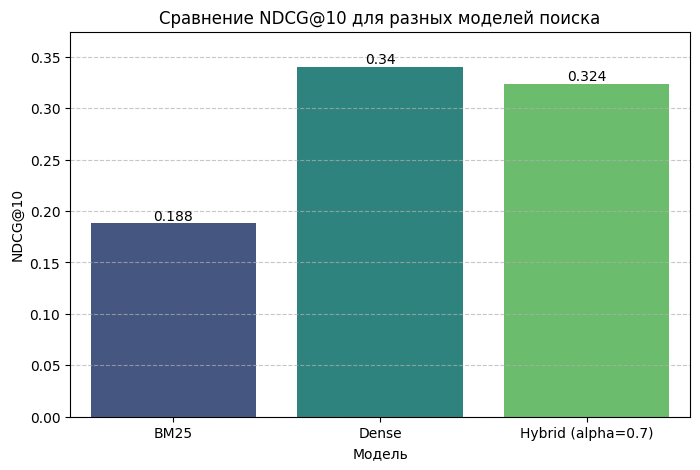

In [31]:
# это мне colab посоветовал добавить
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# NDCG@10 scores from previous execution results (taken at k=10)
ndcg_scores = {
    'BM25': 0.18828426650512678,
    'Dense': 0.3401931524916533, # From Dense @ 10
    'Hybrid (alpha=0.7)': 0.3237151454084375 # From Hybrid @ 10 (alpha=0.7 used in cell 25)
}

# Convert to DataFrame for easier plotting
df_ndcg = pd.DataFrame(list(ndcg_scores.items()), columns=['Model', 'NDCG@10'])

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='NDCG@10', data=df_ndcg, palette='viridis')
plt.title('Сравнение NDCG@10 для разных моделей поиска')
plt.ylabel('NDCG@10')
plt.xlabel('Модель')
plt.ylim(0, df_ndcg['NDCG@10'].max() * 1.1) # Set y-limit slightly above max for better visualization

# Add values on top of bars
for index, row in df_ndcg.iterrows():
    plt.text(index, row['NDCG@10'], round(row['NDCG@10'], 3), color='black', ha="center", va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()